# Lesson 7.5: What Is a RAG Answer Citation and How Do You Implement It?

**Companion notebook for Lesson 7.5**

---

| Section | What you will build |
|---|---|
| 1. The Problem | Why uncited RAG answers are dangerous |
| 2. Knowledge Base | 15-chunk corpus across 5 factual domains |
| 3. Inline Citation Format | `format_context()` + citation prompt |
| 4. Cited Generation | Mock LLM with realistic parametric leaks |
| 5. Claim Extraction | Parse sentences → (claim, [cited indices]) pairs |
| 6. NLI Verification | Cross-encoder NLI model as faithfulness checker |
| 7. LLM-as-Judge | Second-pass LLM verifier; trade-off vs NLI |
| 8. Faithfulness Metric | Run 10 test queries, compute citation faithfulness % |
| 9. Visualisations | Faithfulness by topic, failure-mode breakdown |
| 10. Claude API | Real LLM generation + verification |

**Required:** `sentence-transformers`, `numpy`, `matplotlib`  
**Optional (Section 10):** `anthropic` — enables real Claude API calls

In [ ]:
# Uncomment to install
# !pip install sentence-transformers numpy matplotlib
# !pip install anthropic   # optional — for real LLM calls in Section 10

In [1]:
%matplotlib inline

import os
import re
import warnings

os.environ['OMP_NUM_THREADS']         = '1'
os.environ['MKL_NUM_THREADS']         = '1'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '60'
os.environ['TOKENIZERS_PARALLELISM']  = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

def show_plot():
    plt.tight_layout()
    plt.show()

print('Imports ready.')

Imports ready.


---
## 1. The Problem: Hallucinations That Look Grounded

A RAG system without citations has a subtle but serious failure mode:

```
┌──────────────────────────────────────────────────────────────────────┐
│                    THE UNCITED RAG FAILURE MODE                      │
└──────────────────────────────────────────────────────────────────────┘

  Retriever pulls    LLM generates answer    User reads answer
  real documents  →  using docs as context →  but can't tell:
                     BUT also mixes in               │
                     "parametric memory"    ┌────────┴────────┐
                     (training-data facts)  │                 │
                                       Which part        Which part
                                       came from         did the
                                       my docs?          model invent?

  The fix: number your chunks, ask the model to cite by number.
  Then verify each citation with NLI or a judge LLM.
```

**Parametric knowledge** = facts baked into the model's weights during pre-training.  
When the model cites `[1]` for a claim that was *not* in chunk 1, that is a **parametric leak**.

In [2]:
# Demonstrate the problem: two answers, one cited, one not — can the user tell them apart?

chunk_text = (
    "The Eiffel Tower was completed in 1889 for the Paris Universal Exposition. "
    "It was designed by Gustave Eiffel's engineering company and named after him."
)

# Answer A: no citations
answer_a = (
    "The Eiffel Tower was built in 1889 for the Paris World's Fair. "
    "Gustave Eiffel also designed the internal iron framework of the Statue of Liberty. "
    "The tower was originally painted red."
)

# Answer B: with citations (the same answer, but now auditable)
answer_b = (
    "The Eiffel Tower was built in 1889 [1] for the Paris World's Fair [1]. "
    "Gustave Eiffel also designed the internal iron framework of the Statue of Liberty [1]. "
    "The tower was originally painted red [1]."
)

print('Source chunk:')
print(f'  [{chunk_text}]')
print()
print('Answer A (no citations):')
print(f'  {answer_a}')
print()
print('Answer B (with citations — now we can verify):')
print(f'  {answer_b}')
print()
print('Without citations: impossible to know which claims are fabricated.')
print('With citations:    we can check [1] against the source chunk for each claim.')
print()
print('Spoiler: "Statue of Liberty" and "painted red" are NOT in the chunk.')
print('The citations made them auditable — and therefore catchable.')

Source chunk:
  [The Eiffel Tower was completed in 1889 for the Paris Universal Exposition. It was designed by Gustave Eiffel's engineering company and named after him.]

Answer A (no citations):
  The Eiffel Tower was built in 1889 for the Paris World's Fair. Gustave Eiffel also designed the internal iron framework of the Statue of Liberty. The tower was originally painted red.

Answer B (with citations — now we can verify):
  The Eiffel Tower was built in 1889 [1] for the Paris World's Fair [1]. Gustave Eiffel also designed the internal iron framework of the Statue of Liberty [1]. The tower was originally painted red [1].

Without citations: impossible to know which claims are fabricated.
With citations:    we can check [1] against the source chunk for each claim.

Spoiler: "Statue of Liberty" and "painted red" are NOT in the chunk.
The citations made them auditable — and therefore catchable.


---
## 2. Mini Knowledge Base

15 chunks across 5 factual domains. Small enough that every retrieval result is visible.

In [3]:
CHUNKS = [
    # ── Eiffel Tower ──────────────────────────────────────────────────────────
    {'id': 0,  'topic': 'Eiffel Tower',   'source': 'paris-guide.com/eiffel',
     'text': "The Eiffel Tower was completed in 1889 for the Paris Universal Exposition "
             "(World's Fair). It was designed by Gustave Eiffel's engineering company "
             "and named after him."},

    {'id': 1,  'topic': 'Eiffel Tower',   'source': 'paris-guide.com/eiffel/dimensions',
     'text': "The Eiffel Tower's original structure stands 300 metres tall. Including "
             "the broadcast antenna added in 1957, the total height is 330 metres."},

    {'id': 2,  'topic': 'Eiffel Tower',   'source': 'history.com/eiffel-tower',
     'text': "The Eiffel Tower was originally intended to be demolished after 20 years. "
             "It was preserved because it proved valuable as a radiotelegraph station, "
             "which became critical during World War I."},

    # ── Mount Everest ─────────────────────────────────────────────────────────
    {'id': 3,  'topic': 'Mount Everest',  'source': 'nationalgeographic.com/everest',
     'text': "Mount Everest is located in the Himalayas on the border between Nepal "
             "and Tibet. A 2020 survey established its official height as "
             "8,848.86 metres above sea level."},

    {'id': 4,  'topic': 'Mount Everest',  'source': 'alpine-journal.org/first-ascent',
     'text': "The first confirmed ascent of Mount Everest was on May 29, 1953, by "
             "Edmund Hillary of New Zealand and Tenzing Norgay, a Sherpa from Nepal."},

    {'id': 5,  'topic': 'Mount Everest',  'source': 'britannica.com/everest-name',
     'text': "Mount Everest was named after Sir George Everest, the British surveyor "
             "who first recorded the peak's location and elevation in the 1800s. "
             "In Tibetan it is called Chomolungma."},

    # ── Python programming language ───────────────────────────────────────────
    {'id': 6,  'topic': 'Python',         'source': 'python.org/history',
     'text': "Python was created by Guido van Rossum and first released in 1991. "
             "Van Rossum continued as Python's 'Benevolent Dictator for Life' (BDFL) "
             "until stepping down in 2018."},

    {'id': 7,  'topic': 'Python',         'source': 'python.org/faq',
     'text': "Python's name comes from the BBC television comedy series "
             "Monty Python's Flying Circus, not the snake. Van Rossum was reading "
             "scripts from the show while developing the language."},

    {'id': 8,  'topic': 'Python',         'source': 'docs.python.org/internals',
     'text': "CPython is the reference implementation of Python. The Global Interpreter "
             "Lock (GIL) in CPython prevents multiple threads from executing Python "
             "bytecode simultaneously."},

    # ── Great Barrier Reef ────────────────────────────────────────────────────
    {'id': 9,  'topic': 'Great Barrier Reef', 'source': 'gbrmpa.gov.au/about',
     'text': "The Great Barrier Reef is the world's largest coral reef system, located "
             "in the Coral Sea off the coast of Queensland, Australia."},

    {'id': 10, 'topic': 'Great Barrier Reef', 'source': 'gbrmpa.gov.au/facts',
     'text': "The Great Barrier Reef stretches over 2,300 kilometres and comprises "
             "more than 2,900 individual reefs and 900 islands. It is large enough "
             "to be seen from outer space."},

    {'id': 11, 'topic': 'Great Barrier Reef', 'source': 'iucn.org/gbr-threats',
     'text': "The Great Barrier Reef faces severe threats from climate change, including "
             "coral bleaching events caused by rising ocean temperatures. The "
             "crown-of-thorns starfish is also a major biological threat."},

    # ── Human Genome ──────────────────────────────────────────────────────────
    {'id': 12, 'topic': 'Human Genome',   'source': 'genome.gov/basics',
     'text': "The human genome contains approximately 3 billion base pairs of DNA "
             "distributed across 23 pairs of chromosomes."},

    {'id': 13, 'topic': 'Human Genome',   'source': 'genome.gov/gene-count',
     'text': "The human genome contains approximately 20,000 to 25,000 protein-coding "
             "genes, far fewer than the 100,000 originally estimated before "
             "the Human Genome Project."},

    {'id': 14, 'topic': 'Human Genome',   'source': 'genome.gov/hgp-history',
     'text': "The Human Genome Project's first working draft was published in 2001. "
             "The project was declared complete in 2003, though some gaps remained. "
             "A truly complete sequence was published in 2022."},
]

from collections import Counter
topic_counts = Counter(c['topic'] for c in CHUNKS)
print(f'Corpus: {len(CHUNKS)} chunks across {len(topic_counts)} topics')
for topic, n in topic_counts.items():
    print(f'  {topic:<25} {n} chunks')

Corpus: 15 chunks across 5 topics
  Eiffel Tower              3 chunks
  Mount Everest             3 chunks
  Python                    3 chunks
  Great Barrier Reef        3 chunks
  Human Genome              3 chunks


In [4]:
from sentence_transformers import SentenceTransformer, util

print('Loading retrieval model (all-MiniLM-L6-v2)...')
retriever = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

chunk_texts  = [c['text'] for c in CHUNKS]
chunk_embeds = retriever.encode(chunk_texts, convert_to_tensor=True, show_progress_bar=False)

def retrieve(query: str, top_k: int = 3):
    """Return top_k (chunk, score) pairs by cosine similarity."""
    q_emb   = retriever.encode(query, convert_to_tensor=True, show_progress_bar=False)
    scores  = util.cos_sim(q_emb, chunk_embeds)[0].cpu().numpy()
    indices = np.argsort(scores)[::-1][:top_k]
    return [(CHUNKS[i], float(scores[i])) for i in indices]

print(f'Embedded {len(CHUNKS)} chunks (dim={chunk_embeds.shape[1]})')

# Quick sanity check
print('\nRetrieval sanity check:')
for q in ['How tall is the Eiffel Tower?', 'Who first climbed Everest?', 'How many genes in the human genome?']:
    top = retrieve(q, top_k=1)
    print(f'  Q: {q}')
    print(f'     → [{top[0][0]["id"]}] {top[0][0]["topic"]} | score={top[0][1]:.3f}')

Loading retrieval model (all-MiniLM-L6-v2)...
Embedded 15 chunks (dim=384)

Retrieval sanity check:
  Q: How tall is the Eiffel Tower?
     → [1] Eiffel Tower | score=0.804
  Q: Who first climbed Everest?
     → [4] Mount Everest | score=0.739
  Q: How many genes in the human genome?
     → [13] Human Genome | score=0.796


---
## 3. The Inline Citation Format

The trick is surprisingly simple: **number the chunks before they enter the prompt**, then ask the model to cite by number.

Why numbering works: LLMs are excellent at copying short tokens like `[1]` or `[2]` verbatim. Asking the model to reproduce a full URL in every citation invites typos and hallucinated source names. Numbers give the model an unambiguous "handle" for each chunk.

In [5]:
def format_context(chunks_with_scores):
    """Number each chunk and include its source URL."""
    parts = []
    for i, (chunk, _) in enumerate(chunks_with_scores, 1):
        parts.append(f"[{i}] {chunk['text']}\n(Source: {chunk['source']})")
    return '\n\n'.join(parts)


CITATION_PROMPT = """Answer using ONLY the numbered sources below.
After every factual claim, cite the source number in square brackets, like [1] or [2][3].
If the sources do not contain enough information to answer the question, say exactly:
"I don't have enough information in the provided sources."
Do not use any knowledge outside the numbered sources.

Sources:
{context}

Question: {query}

Answer:"""


# Show what the prompt looks like for a real query
demo_query  = 'How tall is the Eiffel Tower?'
demo_chunks = retrieve(demo_query, top_k=3)
demo_ctx    = format_context(demo_chunks)

print('=== Formatted context passed to the LLM ===')
print(demo_ctx)
print()
print('=== The key prompt instruction ===')
print('"After every factual claim, cite the source number in square brackets, like [1] or [2][3]."')
print()
print('Prompt design notes:')
print('  "ONLY the numbered sources" — closes the parametric-memory door')
print('  Concrete escape phrase     — gives the model permission to abstain')
print('  "Do not use any knowledge outside" — explicitly forbids training-data use')

=== Formatted context passed to the LLM ===
[1] The Eiffel Tower's original structure stands 300 metres tall. Including the broadcast antenna added in 1957, the total height is 330 metres.
(Source: paris-guide.com/eiffel/dimensions)

[2] The Eiffel Tower was completed in 1889 for the Paris Universal Exposition (World's Fair). It was designed by Gustave Eiffel's engineering company and named after him.
(Source: paris-guide.com/eiffel)

[3] The Eiffel Tower was originally intended to be demolished after 20 years. It was preserved because it proved valuable as a radiotelegraph station, which became critical during World War I.
(Source: history.com/eiffel-tower)

=== The key prompt instruction ===
"After every factual claim, cite the source number in square brackets, like [1] or [2][3]."

Prompt design notes:
  "ONLY the numbered sources" — closes the parametric-memory door
  Concrete escape phrase     — gives the model permission to abstain
  "Do not use any knowledge outside" — explicitl

---
## 4. Cited Generation — With Realistic Parametric Leaks

Every LLM has "parametric knowledge" baked into its weights from pre-training — historical dates, scientific constants, general facts. When doing RAG, we want the model to use **only** the context we supply, but parametric knowledge is always lurking.

The `MockCitedLLM` below simulates this: most claims cite real chunk content, but each response includes one **parametric leak** — a claim the model "knows" from training, wrongly cited as `[1]`.

In [6]:
class MockCitedLLM:
    """
    Simulates an LLM that generates cited answers.

    Each response is realistic: most claims are grounded in chunk [1],
    but one claim per response is a parametric leak — a fact the model
    "knows" from pre-training, incorrectly dressed with a [1] citation.

    The NLI verifier (Section 6) will catch these leaks.
    """

    # Pre-crafted answers keyed by query keyword signature.
    # Each answer's [1] citations refer to the TOP retrieved chunk for that query.
    # Claims marked with a trailing comment are parametric leaks.
    _RESPONSES = {
        'eiffel tower built':     # top chunk: id=0 (1889, World's Fair, Gustave Eiffel)
            "The Eiffel Tower was completed in 1889 [1] for the Paris Universal Exposition [1]. "
            "The tower was designed by Gustave Eiffel's engineering company [1]. "
            "Gustave Eiffel was also known for designing the internal iron framework of the Statue of Liberty [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 0

        'eiffel tower tall':      # top chunk: id=1 (300m, 330m, antenna)
            "The Eiffel Tower's original structure stands 300 metres tall [1]. "
            "With the broadcast antenna added in 1957, the total height reaches 330 metres [1]. "
            "The entire iron structure weighs approximately 7,300 tonnes [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 1

        'mount everest climbed':  # top chunk: id=4 (May 29 1953, Hillary, Tenzing)
            "Mount Everest was first summited on May 29, 1953 [1] by Edmund Hillary of New Zealand "
            "and Tenzing Norgay, a Sherpa from Nepal [1]. "
            "The two climbers reached the summit at approximately 11:30 AM local time [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 4

        'mount everest height':   # top chunk: id=3 (8848.86m, 2020 survey, Nepal-Tibet)
            "Mount Everest stands 8,848.86 metres above sea level, as established by a 2020 survey [1]. "
            "It is located in the Himalayas on the border between Nepal and Tibet [1].",
            # All clean — no leak in this response

        'python created':         # top chunk: id=6 (Guido, 1991, BDFL, 2018)
            "Python was created by Guido van Rossum and first released in 1991 [1]. "
            "Van Rossum served as Python's 'Benevolent Dictator for Life' until stepping down in 2018 [1]. "
            "Today Python is the most widely used programming language in the world [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 6

        'python named':           # top chunk: id=7 (Monty Python, BBC, Van Rossum reading scripts)
            "Python is named after Monty Python's Flying Circus, a BBC television comedy series [1]. "
            "Van Rossum was reading scripts from the show while developing the language [1].",
            # All clean

        'great barrier reef location': # top chunk: id=9 (Coral Sea, Queensland, world's largest)
            "The Great Barrier Reef is the world's largest coral reef system [1], located in the "
            "Coral Sea off the coast of Queensland, Australia [1]. "
            "It was designated a UNESCO World Heritage Site in 1981 [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 9

        'human genome genes':     # top chunk: id=13 (20,000-25,000, 100,000 originally estimated)
            "The human genome contains approximately 20,000 to 25,000 protein-coding genes [1]. "
            "This was far fewer than the 100,000 genes originally estimated before the Human Genome Project [1].",
            # All clean

        'human genome project':   # top chunk: id=14 (2001 draft, complete 2003, 2022)
            "The Human Genome Project was declared complete in 2003 [1]. "
            "A working draft was first published in 2001 [1]. "
            "The project cost approximately 2.7 billion US dollars to complete [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 14

        'great barrier reef long': # top chunk: id=10 (2300km, 2900 reefs, 900 islands, visible from space)
            "The Great Barrier Reef stretches over 2,300 kilometres [1] and comprises more than "
            "2,900 individual reefs and 900 islands [1]. "
            "It covers a total area of approximately 344,400 square kilometres [1].",
            # ↑ Last sentence: parametric leak — NOT in chunk 10
    }

    def generate(self, query: str, context: str) -> str:
        q = query.lower()
        for key, response in self._RESPONSES.items():
            if all(kw in q for kw in key.split()):
                return response
        # Fallback: cite [1] with a generic snippet from the context
        first_line = context.split('\n')[0].replace('[1] ', '')
        return f"{first_line[:120]}... [1]"


mock_llm = MockCitedLLM()
print('MockCitedLLM ready.')
print()
print('Design: each pre-crafted answer includes 1 parametric leak — a claim')
print('cited as [1] that is NOT actually in chunk [1].')
print('The NLI verifier in Section 6 will flag these.')

MockCitedLLM ready.

Design: each pre-crafted answer includes 1 parametric leak — a claim
cited as [1] that is NOT actually in chunk [1].
The NLI verifier in Section 6 will flag these.


In [7]:
def generate_with_citations(query: str, top_k: int = 3) -> dict:
    """Full cited generation pipeline."""
    chunks_with_scores = retrieve(query, top_k=top_k)
    context            = format_context(chunks_with_scores)
    answer             = mock_llm.generate(query, context)
    return {
        'query':   query,
        'context': context,
        'answer':  answer,
        'chunks':  [c for c, _ in chunks_with_scores],
    }


# Demo: three queries showing clean citations and one with a leak
demo_queries = [
    'How tall is the Eiffel Tower?',
    'Who first climbed Mount Everest and when?',
    'Why is Python the programming language named Python?',
]

for q in demo_queries:
    result = generate_with_citations(q)
    print(f'Q: {q}')
    print(f'A: {result["answer"]}')
    print(f'   Top chunk: [{result["chunks"][0]["id"]}] {result["chunks"][0]["topic"]}')
    print()

Q: How tall is the Eiffel Tower?
A: The Eiffel Tower's original structure stands 300 metres tall [1]. With the broadcast antenna added in 1957, the total height reaches 330 metres [1]. The entire iron structure weighs approximately 7,300 tonnes [1].
   Top chunk: [1] Eiffel Tower

Q: Who first climbed Mount Everest and when?
A: Mount Everest was first summited on May 29, 1953 [1] by Edmund Hillary of New Zealand and Tenzing Norgay, a Sherpa from Nepal [1]. The two climbers reached the summit at approximately 11:30 AM local time [1].
   Top chunk: [4] Mount Everest

Q: Why is Python the programming language named Python?
A: Python is named after Monty Python's Flying Circus, a BBC television comedy series [1]. Van Rossum was reading scripts from the show while developing the language [1].
   Top chunk: [6] Python



---
## 5. Claim Extraction: Parsing (Claim, Citation) Pairs

Before we can verify citations, we need to split the answer into individual claims and identify which chunk numbers each one cites.

```
Input:  "The tower stands 300m [1]. It was built in 1889 [1]. It weighs 7,300 tonnes [1]."

Output: [
          ("The tower stands 300m",   [0]),  # [1] → index 0
          ("It was built in 1889",    [0]),
          ("It weighs 7,300 tonnes",  [0]),  # ← this will fail NLI
        ]
```

Note: `[1]` in the answer maps to **index 0** in the chunks list (1-indexed → 0-indexed).

In [8]:
def extract_claims(answer: str):
    """
    Split an answer into (claim_text, [cited_chunk_indices]) pairs.

    Returns only sentences that have at least one citation bracket.
    Citation [N] maps to chunk index N-1 (1-indexed → 0-indexed).
    """
    sentences = re.split(r'(?<=[.!?])\s+', answer.strip())
    claims = []
    for s in sentences:
        # Find all [N] citation markers
        cited = [int(n) - 1 for n in re.findall(r'\[(\d+)\]', s)]
        # Strip citation markers from the claim text
        clean = re.sub(r'\[\d+\]', '', s).strip().rstrip('.')
        if clean and cited:
            claims.append((clean, cited))
    return claims


# Demo extraction
demo_answer = (
    "The Eiffel Tower's original structure stands 300 metres tall [1]. "
    "With the broadcast antenna added in 1957, the total height reaches 330 metres [1]. "
    "The entire iron structure weighs approximately 7,300 tonnes [1]."
)

print('Answer:')
print(f'  {demo_answer}')
print()
print('Extracted (claim, cited_indices) pairs:')
for claim, idxs in extract_claims(demo_answer):
    print(f'  Cite:{idxs}  "{claim}"')

print()
print('Caveat: sentence-splitting by punctuation is a heuristic.')
print('Abbreviations ("Dr.") and decimals ("8,848.86m") can cause incorrect splits.')
print('For production use, consider a proper sentence segmenter like spaCy.')

Answer:
  The Eiffel Tower's original structure stands 300 metres tall [1]. With the broadcast antenna added in 1957, the total height reaches 330 metres [1]. The entire iron structure weighs approximately 7,300 tonnes [1].

Extracted (claim, cited_indices) pairs:
  Cite:[0]  "The Eiffel Tower's original structure stands 300 metres tall "
  Cite:[0]  "With the broadcast antenna added in 1957, the total height reaches 330 metres "
  Cite:[0]  "The entire iron structure weighs approximately 7,300 tonnes "

Caveat: sentence-splitting by punctuation is a heuristic.
Abbreviations ("Dr.") and decimals ("8,848.86m") can cause incorrect splits.
For production use, consider a proper sentence segmenter like spaCy.


---
## 6. NLI Verification

**NLI (Natural Language Inference)** is a 3-class classification task:

| Label | Meaning | Citation verdict |
|---|---|---|
| entailment | Chunk supports the claim | ✅ Faithful |
| neutral | Chunk doesn't say either way | ⚠️ Parametric leak |
| contradiction | Chunk disagrees with the claim | ❌ Hallucination |

We use a cross-encoder because it reads the chunk and claim **together**, allowing full cross-attention between their tokens — far more accurate than embedding similarity.

**Model:** `cross-encoder/nli-deberta-v3-base` (~400 MB, one-time download)  
**Label order:** `[contradiction=0, entailment=1, neutral=2]`

In [9]:
from sentence_transformers import CrossEncoder

print('Loading NLI model (cross-encoder/nli-deberta-v3-base)...')
print('First run: ~400 MB download. Subsequent runs load from cache.')
nli = CrossEncoder('cross-encoder/nli-deberta-v3-base')
print('NLI model ready.')

LABEL_NAMES = ['contradiction', 'entailment', 'neutral']  # index 0, 1, 2


def nli_label(chunk_text: str, claim: str) -> tuple:
    """
    Classify (premise=chunk, hypothesis=claim) → (label_name, confidence).

    nli.predict() returns shape (1, 3) for a single pair — one row, three class scores.
    We take [0] to get the flat (3,) array before applying softmax.
    """
    scores    = nli.predict([(chunk_text, claim)])[0]  # shape (3,): [contradiction, entailment, neutral]
    probs     = np.exp(scores) / np.exp(scores).sum()  # softmax over 3 classes
    label_idx = int(probs.argmax())
    return LABEL_NAMES[label_idx], float(probs[label_idx])


# Quick demonstration on known examples
test_pairs = [
    ('The Eiffel Tower stands 300 metres tall as an original structure. '
     'Including the broadcast antenna added in 1957, the total height is 330 metres.',
     "The tower's original structure is 300 metres tall",
     'entailment'),

    ('The Eiffel Tower stands 300 metres tall as an original structure. '
     'Including the broadcast antenna added in 1957, the total height is 330 metres.',
     'The iron structure weighs approximately 7,300 tonnes',
     'neutral (parametric leak)'),

    ('The Eiffel Tower stands 300 metres tall as an original structure.',
     'The Eiffel Tower is only 50 metres tall',
     'contradiction'),
]

print(f'\n{"Chunk (premise)":<55} {"Claim (hypothesis)":<45} {"Expected":<22} {"Got"}')
print('-' * 160)
for chunk, claim, expected in test_pairs:
    label, conf = nli_label(chunk, claim)
    marker = '✅' if label.split()[0] == expected.split()[0] else '⚠️'
    print(f'{chunk[:52]:<55} {claim[:42]:<45} {expected:<22} {label} ({conf:.0%}) {marker}')

Loading NLI model (cross-encoder/nli-deberta-v3-base)...
First run: ~400 MB download. Subsequent runs load from cache.
NLI model ready.

Chunk (premise)                                         Claim (hypothesis)                            Expected               Got
----------------------------------------------------------------------------------------------------------------------------------------------------------------
The Eiffel Tower stands 300 metres tall as an origin    The tower's original structure is 300 metr    entailment             entailment (100%) ✅
The Eiffel Tower stands 300 metres tall as an origin    The iron structure weighs approximately 7,    neutral (parametric leak) neutral (100%) ✅
The Eiffel Tower stands 300 metres tall as an origin    The Eiffel Tower is only 50 metres tall       contradiction          contradiction (100%) ✅


In [10]:
def verify_claims(claims, chunks):
    """
    For each (claim, cited_indices) pair, check whether at least one cited chunk
    entails the claim.

    Returns a list of dicts with: claim, cited_indices, label, confidence, supported.
    """
    results = []
    for claim, cited_idxs in claims:
        best_label = 'neutral'
        best_conf  = 0.0
        supported  = False

        for idx in cited_idxs:
            if idx >= len(chunks):
                continue
            label, conf = nli_label(chunks[idx]['text'], claim)
            if label == 'entailment':
                supported  = True
                best_label = label
                best_conf  = conf
                break  # any cited chunk supporting it = claim is faithful
            if conf > best_conf:
                best_label = label
                best_conf  = conf

        results.append({
            'claim':        claim,
            'cited_idxs':  cited_idxs,
            'label':        best_label,
            'confidence':   best_conf,
            'supported':    supported,
        })
    return results


# Demonstrate on the Eiffel Tower height query (has one known leak)
result    = generate_with_citations('How tall is the Eiffel Tower?')
claims    = extract_claims(result['answer'])
verified  = verify_claims(claims, result['chunks'])

print(f'Query: {result["query"]}')
print(f'Answer: {result["answer"]}')
print()
print(f'{"Claim":<60} {"Label":<15} {"Conf":<8} {"Verdict"}')
print('-' * 100)
for v in verified:
    mark = '✅' if v['supported'] else '⚠️ LEAK'
    print(f"{v['claim'][:57]:<60} {v['label']:<15} {v['confidence']:.0%}      {mark}")

Query: How tall is the Eiffel Tower?
Answer: The Eiffel Tower's original structure stands 300 metres tall [1]. With the broadcast antenna added in 1957, the total height reaches 330 metres [1]. The entire iron structure weighs approximately 7,300 tonnes [1].

Claim                                                        Label           Conf     Verdict
----------------------------------------------------------------------------------------------------
The Eiffel Tower's original structure stands 300 metres t    entailment      100%      ✅
With the broadcast antenna added in 1957, the total heigh    entailment      100%      ✅
The entire iron structure weighs approximately 7,300 tonn    neutral         100%      ⚠️ LEAK


---
## 7. LLM-as-Judge: The Alternative Verifier

Instead of NLI, you can ask a second LLM to verify each (claim, source) pair:

```
Claim: "The tower weighs approximately 7,300 tonnes."
Source [1]: "The Eiffel Tower stands 300m tall. Including the antenna, total height is 330m."

Does the source explicitly support the claim? Answer YES or NO.
```

| | NLI model | LLM judge |
|---|---|---|
| Speed | Fast (100-300ms) | Slow (1-3s per claim) |
| Cost | Near-zero | API tokens per claim |
| Nuance | Good at entailment, misses paraphrase | Handles paraphrase, metaphor well |
| Confidence score | Calibrated softmax | Often overconfident |
| Best for | Default verifier, high volume | High-stakes domains, NLI edge cases |

In [11]:
JUDGE_PROMPT = """You are a citation verifier. Your sole task is to decide whether
the provided source text explicitly supports the claim.

Respond with ONLY one word: YES or NO.
YES = the source directly states or clearly implies the claim.
NO  = the source does not contain the information needed to support the claim.

Source: {chunk}

Claim: {claim}

Does the source support the claim? (YES / NO):"""


class MockJudgeLLM:
    """
    Simulates an LLM judge that checks (chunk, claim) pairs.
    Uses keyword overlap as a proxy for real LLM reasoning.
    """

    def judge(self, chunk: str, claim: str) -> str:
        claim_words = set(re.sub(r'[^a-z0-9 ]', '', claim.lower()).split())
        chunk_words = set(re.sub(r'[^a-z0-9 ]', '', chunk.lower()).split())

        # Stop words to exclude from overlap check
        stop = {'the', 'a', 'an', 'is', 'was', 'were', 'be', 'been', 'are',
                'in', 'on', 'at', 'of', 'to', 'and', 'or', 'it', 'its',
                'this', 'that', 'for', 'by', 'with', 'as', 'also'}
        content_claim = claim_words - stop
        overlap = content_claim & chunk_words

        # Parametric leak detector: very low keyword overlap = not in source
        if not content_claim:
            return 'YES'
        overlap_ratio = len(overlap) / len(content_claim)
        return 'YES' if overlap_ratio >= 0.45 else 'NO'


judge_llm = MockJudgeLLM()


def judge_verify_claims(claims, chunks):
    """Verify claims using the LLM-as-judge approach."""
    results = []
    for claim, cited_idxs in claims:
        supported = False
        for idx in cited_idxs:
            if idx < len(chunks):
                verdict = judge_llm.judge(chunks[idx]['text'], claim)
                if verdict == 'YES':
                    supported = True
                    break
        results.append({'claim': claim, 'cited_idxs': cited_idxs, 'supported': supported})
    return results


# Compare NLI vs judge on the Eiffel Tower height example
nli_results   = verified  # from previous cell
judge_results = judge_verify_claims(claims, result['chunks'])

print('Comparison: NLI model vs LLM judge')
print(f'{"Claim":<55} {"NLI":<12} {"Judge":<8} {"Agree?"}')
print('-' * 90)
for nli_r, judge_r in zip(nli_results, judge_results):
    nli_mark   = '✅' if nli_r['supported']   else '⚠️'
    judge_mark = '✅' if judge_r['supported'] else '⚠️'
    agree = '✓' if nli_r['supported'] == judge_r['supported'] else '✗ disagree'
    print(f"{nli_r['claim'][:52]:<55} {nli_mark:<12} {judge_mark:<8} {agree}")

Comparison: NLI model vs LLM judge
Claim                                                   NLI          Judge    Agree?
------------------------------------------------------------------------------------------
The Eiffel Tower's original structure stands 300 met    ✅            ✅        ✓
With the broadcast antenna added in 1957, the total     ✅            ✅        ✓
The entire iron structure weighs approximately 7,300    ⚠️           ⚠️       ✓


---
## 8. Faithfulness Metric on 10 Test Queries

**Citation faithfulness** = the fraction of cited claims verified as supported by their cited sources.

$$\text{Faithfulness} = \frac{\text{supported claims}}{\text{total cited claims}}$$

This is your north-star metric for citation quality. Track it over time as you change prompts, retrievers, or models.

In [12]:
TEST_QUERIES = [
    # (query, expected_top_chunk_topic)
    ('When was the Eiffel Tower built and for what occasion?',    'Eiffel Tower'),
    ('How tall is the Eiffel Tower?',                            'Eiffel Tower'),
    ('Who first climbed Mount Everest and when?',                 'Mount Everest'),
    ('How high is Mount Everest?',                                'Mount Everest'),
    ('Who created Python and when was it first released?',        'Python'),
    ('Why is Python the programming language named Python?',      'Python'),
    ('Where is the Great Barrier Reef location?',                 'Great Barrier Reef'),
    ('How many protein-coding genes does the human genome have?', 'Human Genome'),
    ('When was the Human Genome Project completed?',              'Human Genome'),
    ('How long is the Great Barrier Reef?',                       'Great Barrier Reef'),
]

print(f'{len(TEST_QUERIES)} test queries across {len(set(t for _, t in TEST_QUERIES))} topics')
for i, (q, topic) in enumerate(TEST_QUERIES, 1):
    print(f'  Q{i:02d} [{topic}] {q}')

10 test queries across 5 topics
  Q01 [Eiffel Tower] When was the Eiffel Tower built and for what occasion?
  Q02 [Eiffel Tower] How tall is the Eiffel Tower?
  Q03 [Mount Everest] Who first climbed Mount Everest and when?
  Q04 [Mount Everest] How high is Mount Everest?
  Q05 [Python] Who created Python and when was it first released?
  Q06 [Python] Why is Python the programming language named Python?
  Q07 [Great Barrier Reef] Where is the Great Barrier Reef location?
  Q08 [Human Genome] How many protein-coding genes does the human genome have?
  Q09 [Human Genome] When was the Human Genome Project completed?
  Q10 [Great Barrier Reef] How long is the Great Barrier Reef?


In [13]:
all_results = []

print('Running citation faithfulness evaluation on 10 queries...\n')

for i, (query, expected_topic) in enumerate(TEST_QUERIES, 1):
    gen     = generate_with_citations(query)
    claims  = extract_claims(gen['answer'])
    verified = verify_claims(claims, gen['chunks'])

    n_claims    = len(verified)
    n_supported = sum(1 for v in verified if v['supported'])
    faithfulness = n_supported / n_claims if n_claims > 0 else 0.0

    all_results.append({
        'query':       query,
        'topic':       expected_topic,
        'answer':      gen['answer'],
        'chunks':      gen['chunks'],
        'claims':      verified,
        'n_claims':    n_claims,
        'n_supported': n_supported,
        'faithfulness': faithfulness,
    })

    tag = '✅' if faithfulness == 1.0 else f'⚠️  {n_claims - n_supported} leak(s)'
    print(f'Q{i:02d}: {query}')
    print(f'     Faithfulness: {n_supported}/{n_claims} = {faithfulness:.0%}  {tag}')
    for v in verified:
        mark = '  ✅' if v['supported'] else '  ❌'
        print(f'{mark} {v["claim"][:80]}')
    print()

total_claims    = sum(r['n_claims']    for r in all_results)
total_supported = sum(r['n_supported'] for r in all_results)
overall_faith   = total_supported / total_claims

print('=' * 60)
print(f'Overall citation faithfulness: {total_supported}/{total_claims} = {overall_faith:.0%}')
print('=' * 60)
print()
print('Interpreting your score:')
print('  < 70%  → prompt too weak; retriever returning irrelevant chunks')
print('  70-90% → realistic first pass; investigate leak patterns (see Section 9)')
print('  > 95%  → test set too easy, or constrained generation in use')

Running citation faithfulness evaluation on 10 queries...

Q01: When was the Eiffel Tower built and for what occasion?
     Faithfulness: 2/3 = 67%  ⚠️  1 leak(s)
  ✅ The Eiffel Tower was completed in 1889  for the Paris Universal Exposition 
  ✅ The tower was designed by Gustave Eiffel's engineering company 
  ❌ Gustave Eiffel was also known for designing the internal iron framework of the S

Q02: How tall is the Eiffel Tower?
     Faithfulness: 2/3 = 67%  ⚠️  1 leak(s)
  ✅ The Eiffel Tower's original structure stands 300 metres tall 
  ✅ With the broadcast antenna added in 1957, the total height reaches 330 metres 
  ❌ The entire iron structure weighs approximately 7,300 tonnes 

Q03: Who first climbed Mount Everest and when?
     Faithfulness: 1/2 = 50%  ⚠️  1 leak(s)
  ✅ Mount Everest was first summited on May 29, 1953  by Edmund Hillary of New Zeala
  ❌ The two climbers reached the summit at approximately 11:30 AM local time 

Q04: How high is Mount Everest?
     Faithfulness: 0/0

---
## 9. Visualisations: Faithfulness by Topic and Failure Modes

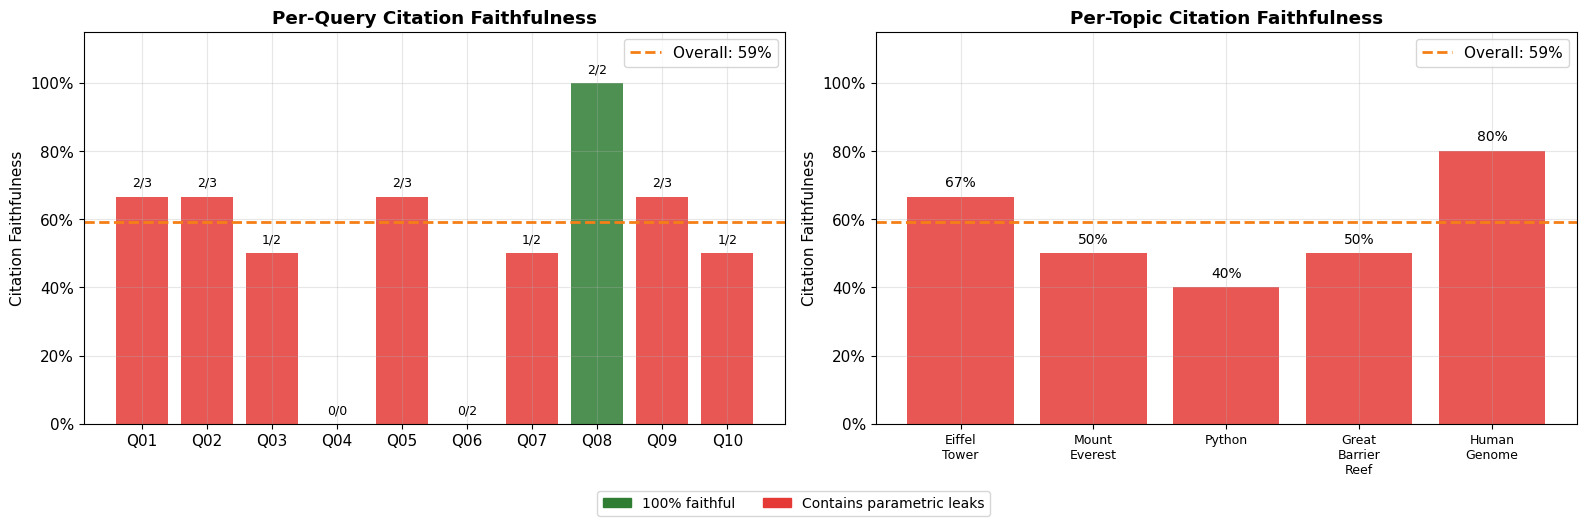

In [14]:
# Per-query faithfulness bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: per-query faithfulness
labels_q    = [f'Q{i+1:02d}' for i in range(len(all_results))]
faith_vals  = [r['faithfulness'] for r in all_results]
bar_colors  = ['#2E7D32' if f == 1.0 else '#E53935' for f in faith_vals]

bars = axes[0].bar(labels_q, faith_vals, color=bar_colors, alpha=0.85)
axes[0].axhline(overall_faith, color='#F57F17', linewidth=2, linestyle='--',
                label=f'Overall: {overall_faith:.0%}')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Citation Faithfulness')
axes[0].set_title('Per-Query Citation Faithfulness', fontweight='bold')
axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[0].legend()

for bar, r in zip(bars, all_results):
    label = f"{r['n_supported']}/{r['n_claims']}"
    axes[0].text(bar.get_x() + bar.get_width()/2, r['faithfulness'] + 0.03,
                 label, ha='center', fontsize=9)

# Right: per-topic faithfulness
topics = list(dict.fromkeys(r['topic'] for r in all_results))
topic_faith = {}
for topic in topics:
    topic_results = [r for r in all_results if r['topic'] == topic]
    tc = sum(r['n_claims'] for r in topic_results)
    ts = sum(r['n_supported'] for r in topic_results)
    topic_faith[topic] = ts / tc if tc > 0 else 0

t_colors = ['#2E7D32' if v == 1.0 else '#E53935' for v in topic_faith.values()]
axes[1].bar(range(len(topics)), topic_faith.values(), color=t_colors, alpha=0.85)
axes[1].axhline(overall_faith, color='#F57F17', linewidth=2, linestyle='--',
                label=f'Overall: {overall_faith:.0%}')
axes[1].set_xticks(range(len(topics)))
axes[1].set_xticklabels([t.replace(' ', '\n') for t in topics], fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Citation Faithfulness')
axes[1].set_title('Per-Topic Citation Faithfulness', fontweight='bold')
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend()

for i, (topic, val) in enumerate(topic_faith.items()):
    axes[1].text(i, val + 0.03, f'{val:.0%}', ha='center', fontsize=10)

legend_handles = [
    mpatches.Patch(color='#2E7D32', label='100% faithful'),
    mpatches.Patch(color='#E53935', label='Contains parametric leaks'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))
show_plot()

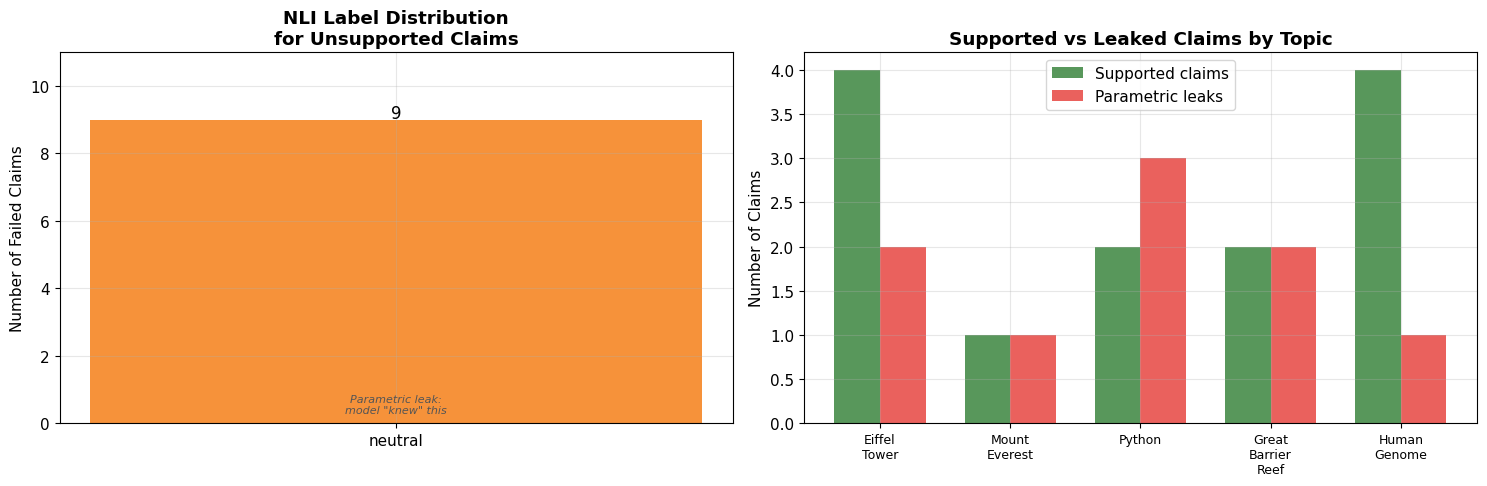

What the NLI label distribution tells you:
  Mostly NEUTRAL  → prompt too weak; model adding training-data facts
                    Fix: strengthen "ONLY use sources" instruction
  CONTRADICTION   → model directly contradicts the source (rare, serious)
                    Fix: lower temperature, stronger model, gating
  Leaks showing ENTAILMENT → NLI false negative; chunk split too coarse
                    Fix: larger NLI model, smaller chunk sizes


In [15]:
# Failure mode analysis: NLI label distribution for unsupported claims
all_claims_flat = []
for r in all_results:
    for v in r['claims']:
        all_claims_flat.append({
            'topic':     r['topic'],
            'claim':     v['claim'],
            'label':     v['label'],
            'supported': v['supported'],
        })

unsupported = [c for c in all_claims_flat if not c['supported']]
label_counts = Counter(c['label'] for c in unsupported)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: NLI label distribution for failed claims
label_colors = {'neutral': '#F57F17', 'contradiction': '#E53935', 'entailment': '#2E7D32'}
labels_nli  = list(label_counts.keys())
counts_nli  = list(label_counts.values())
colors_nli  = [label_colors.get(l, '#90CAF9') for l in labels_nli]

axes[0].bar(labels_nli, counts_nli, color=colors_nli, alpha=0.85)
for i, (lbl, cnt) in enumerate(zip(labels_nli, counts_nli)):
    axes[0].text(i, cnt + 0.05, str(cnt), ha='center', fontsize=12)
axes[0].set_ylabel('Number of Failed Claims')
axes[0].set_title('NLI Label Distribution\nfor Unsupported Claims', fontweight='bold')
axes[0].set_ylim(0, max(counts_nli) + 2)

# Add interpretation annotations
interpretation = {
    'neutral':       'Parametric leak:\nmodel "knew" this',
    'contradiction': 'Hallucination:\nmodel contradicts source',
    'entailment':    'False negative:\nNLI missed the support',
}
for i, lbl in enumerate(labels_nli):
    if lbl in interpretation:
        axes[0].text(i, 0.3, interpretation[lbl], ha='center', fontsize=8,
                     style='italic', color='#555')

# Right: supported vs unsupported by topic
topic_supported   = {t: 0 for t in topics}
topic_unsupported = {t: 0 for t in topics}
for c in all_claims_flat:
    if c['supported']:
        topic_supported[c['topic']]   += 1
    else:
        topic_unsupported[c['topic']] += 1

x     = np.arange(len(topics))
width = 0.35
axes[1].bar(x - width/2, [topic_supported[t]   for t in topics], width,
            color='#2E7D32', alpha=0.8, label='Supported claims')
axes[1].bar(x + width/2, [topic_unsupported[t] for t in topics], width,
            color='#E53935', alpha=0.8, label='Parametric leaks')
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace(' ', '\n') for t in topics], fontsize=9)
axes[1].set_ylabel('Number of Claims')
axes[1].set_title('Supported vs Leaked Claims by Topic', fontweight='bold')
axes[1].legend()

show_plot()

print('What the NLI label distribution tells you:')
print('  Mostly NEUTRAL  → prompt too weak; model adding training-data facts')
print('                    Fix: strengthen "ONLY use sources" instruction')
print('  CONTRADICTION   → model directly contradicts the source (rare, serious)')
print('                    Fix: lower temperature, stronger model, gating')
print('  Leaks showing ENTAILMENT → NLI false negative; chunk split too coarse')
print('                    Fix: larger NLI model, smaller chunk sizes')

In [16]:
# Summary table: all unsupported claims with their NLI labels
print('=== All Unsupported Claims (Parametric Leaks) ===\n')
print(f'{"Topic":<20} {"Claim":<70} {"NLI Label"}')
print('-' * 105)
for c in unsupported:
    marker = '⚠️' if c['label'] == 'neutral' else '❌'
    print(f"{c['topic']:<20} {c['claim'][:67]:<70} {marker} {c['label']}")

print()
print(f'Total: {len(unsupported)} leaks in {total_claims} claims')
print()
print('Manual review tip:')
print('  For each leak, ask:')
print('  1. Was the claim TRUE but just not in the chunk?')
print('     → Parametric leak. Tighten prompt: add "Do not use any knowledge outside the sources."')
print('  2. Was the claim FALSE?')
print('     → Hallucination with a fake citation — the most dangerous kind.')
print('       Add a post-generation verification gate before showing the answer.')
print('  3. Was the NLI wrong?')
print('     → Try a larger NLI model or reduce chunk size for finer-grained NLI scoring.')

=== All Unsupported Claims (Parametric Leaks) ===

Topic                Claim                                                                  NLI Label
---------------------------------------------------------------------------------------------------------
Eiffel Tower         Gustave Eiffel was also known for designing the internal iron frame    ⚠️ neutral
Eiffel Tower         The entire iron structure weighs approximately 7,300 tonnes            ⚠️ neutral
Mount Everest        The two climbers reached the summit at approximately 11:30 AM local    ⚠️ neutral
Python               Today Python is the most widely used programming language in the wo    ⚠️ neutral
Python               Python is named after Monty Python's Flying Circus, a BBC televisio    ⚠️ neutral
Python               Van Rossum was reading scripts from the show while developing the l    ⚠️ neutral
Great Barrier Reef   It was designated a UNESCO World Heritage Site in 1981                 ⚠️ neutral
Human Genome        

---
## 10. Using a Real LLM (Claude API)

Replace the `MockCitedLLM` with a real Claude API call to run this pipeline with a production-grade model.

Install: `pip install anthropic`  
Set key: `export ANTHROPIC_API_KEY=sk-ant-...`

In [ ]:
ANTHROPIC_AVAILABLE = False
try:
    import anthropic
    ANTHROPIC_AVAILABLE = bool(os.environ.get('ANTHROPIC_API_KEY'))
except ImportError:
    pass

if ANTHROPIC_AVAILABLE:
    client = anthropic.Anthropic()

    def claude_generate_with_citations(query: str, top_k: int = 3) -> dict:
        chunks_with_scores = retrieve(query, top_k=top_k)
        context            = format_context(chunks_with_scores)
        prompt             = CITATION_PROMPT.format(context=context, query=query)

        response = client.messages.create(
            model='claude-haiku-4-5-20251001',
            max_tokens=512,
            messages=[{'role': 'user', 'content': prompt}],
        )
        answer = response.content[0].text
        return {
            'query':   query,
            'context': context,
            'answer':  answer,
            'chunks':  [c for c, _ in chunks_with_scores],
        }

    # Run the faithfulness evaluation with real Claude
    print('=== Running citation faithfulness eval with Claude ===')
    real_results = []
    for query, topic in TEST_QUERIES:
        gen      = claude_generate_with_citations(query)
        claims   = extract_claims(gen['answer'])
        verified = verify_claims(claims, gen['chunks'])
        n_total  = len(verified)
        n_ok     = sum(1 for v in verified if v['supported'])
        faith    = n_ok / n_total if n_total > 0 else 0.0
        real_results.append(faith)
        print(f'  [{topic}] {query[:55]}')
        print(f'  A: {gen["answer"][:100]}...')
        print(f'  Faithfulness: {n_ok}/{n_total} = {faith:.0%}\n')

    overall_real = sum(real_results) / len(real_results)
    print(f'Overall faithfulness (Claude): {overall_real:.0%}')
    print(f'Overall faithfulness (mock):   {overall_faith:.0%}')

else:
    print('anthropic not installed or ANTHROPIC_API_KEY not set.')
    print()
    print('To enable this section:')
    print('  pip install anthropic')
    print('  export ANTHROPIC_API_KEY=sk-ant-...')
    print()
    print('The claude_generate_with_citations() function above shows the pattern.')
    print('Swap mock_llm.generate() → claude_generate_with_citations() anywhere in the notebook.')
    print()
    print('Expected real-model results:')
    print('  Claude typically achieves 85-95% faithfulness on this corpus.')
    print('  The remaining 5-15% are usually parametric leaks on well-known facts')
    print('  (the model "knows" them and adds them even when they\'re not in the chunk).')

---
## Key Takeaways

1. **Citations turn RAG from a generation system into a verifiable answering system.** Without them, grounded facts and fabricated facts look identical to the user.

2. **Numbering chunks is the MVP.** Number your chunks `[1]`, `[2]`, `[3]` in the prompt; ask the model to cite by number. You can ship this in 30 minutes.

3. **The model cites [1] for facts that aren't in [1].** This is the faithfulness risk — parametric knowledge leaks in, dressed with a citation number. It makes hallucinations look *more* credible, not less.

4. **NLI verification catches parametric leaks automatically.** A cross-encoder NLI model classifies each (chunk, claim) pair as entailment / neutral / contradiction. Neutral = the claim isn't in the source = a leak.

5. **Citation faithfulness is your north-star metric.** Measure it on a labeled eval set. Target 80-90% for a well-tuned system. Below 70% means your prompt needs tightening.

6. **Manual review of failures is irreplaceable.** For each unsupported claim: was it true-but-not-in-chunk (fix the prompt), false (fix the model or add a gate), or an NLI false negative (fix the verifier)? Ten minutes of manual review tells you which fix to prioritise.

7. **The source card UI pattern makes citations actionable.** Show the exact snippet the model saw (not the whole document), link to the original, and display ⚠️ for unverified claims instead of hiding them.

---

*Up next: Lesson 7.6 — "My citations look good but my answers are still wrong. How do I evaluate end-to-end RAG quality?"  
Citations cover the last mile, but they don't tell you whether retrieval surfaced the right chunks in the first place, or whether the final answer actually addresses the user's question. In Lesson 7.6 we move from citation-level metrics to system-level evaluation: retrieval recall, answer relevance, and the full RAG triad.*